In [11]:
# Importar librerías
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generar datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)



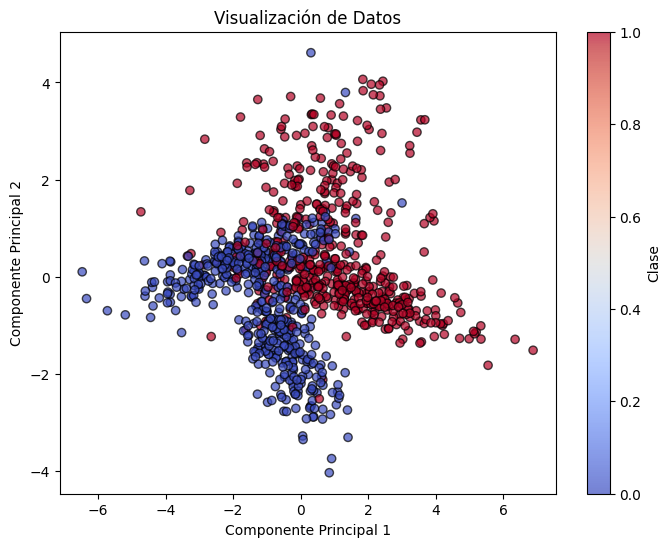

In [12]:
# Importar librerías para visualización
from sklearn.decomposition import PCA

# Reducir dimensionalidad de los datos para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualizar datos
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
plt.title('Visualización de Datos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Clase')
plt.show()

In [13]:
# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Crear modelo de red neuronal
model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, alpha=0.0001, solver='adam', random_state=42)


In [14]:
# Entrenar modelo
model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

In [19]:
# Predecir en conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar modelo
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.81


              precision    recall  f1-score   support

           0       0.78      0.82      0.80        93
           1       0.83      0.80      0.82       107

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



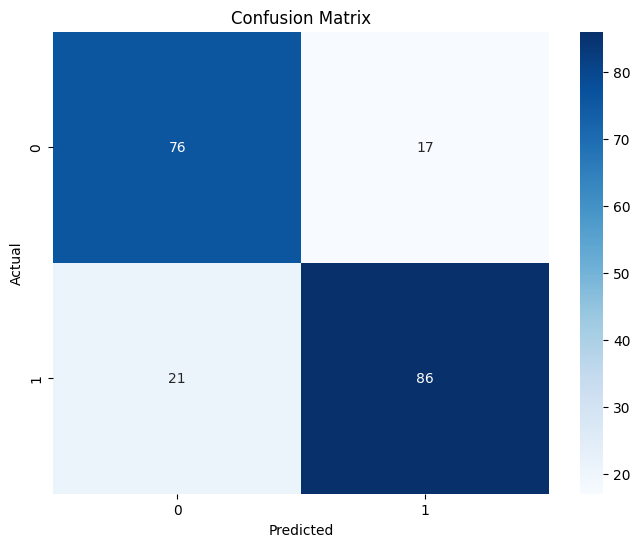

In [20]:
# Métricas de evaluación
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
from sklearn.model_selection import GridSearchCV

h:\Anaconda\envs\IA\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
h:\Anaconda\envs\IA\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
h:\Anaconda\envs\IA\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
h:\Anaconda\envs\IA\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
h:\Anaconda\envs\IA\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:6

Best Model Accuracy: 0.865
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        93
           1       0.91      0.83      0.87       107

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.86       200
weighted avg       0.87      0.86      0.87       200



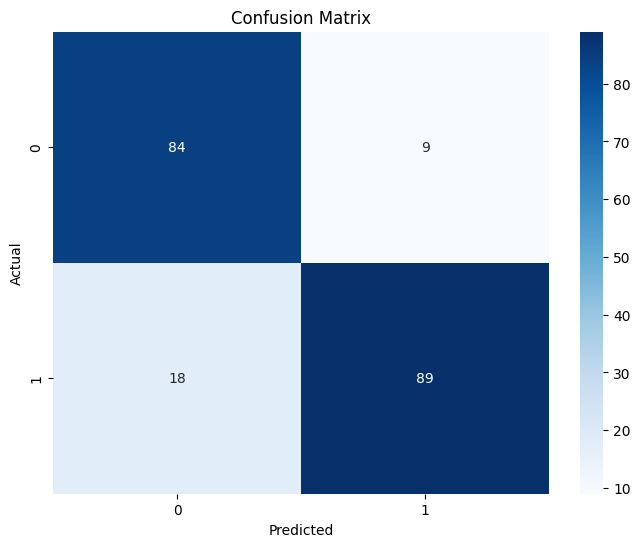

In [10]:
# Definir los parámetros a buscar
parameters = {
    'hidden_layer_sizes': [(10,), (50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh', 'logistic']
}

# Inicializar el modelo de red neuronal
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Inicializar la búsqueda de hiperparámetros
clf = GridSearchCV(mlp, parameters, cv=5)

# Realizar la búsqueda de hiperparámetros
clf.fit(X_train, y_train)

# Obtener el mejor modelo
best_model = clf.best_estimator_

# Entrenar el mejor modelo
best_model.fit(X_train, y_train)

# Predecir en conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluar modelo
accuracy = accuracy_score(y_test, y_pred)
print("Best Model Accuracy:", accuracy)

# Métricas de evaluación
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
clf.best_params_

{'activation': 'logistic', 'hidden_layer_sizes': (50, 50)}

In [26]:
np.shape(best_model.coefs_[0])

(20, 50)